# Train Test Splits, Cross Validation, and Linear Regression

![Lregressions.png](Assets/LinearRegr.png)

# Learning Objectives

- Explain the difference between over-fitting and under-fitting a model
- Describe Bias-variance tradeoffs
- Find the optimal training and test data set splits, cross-validation, and model complexity versus error
- Apply a linear regression model for supervised learning
- Apply Intel® Extension for Scikit-learn* to leverage underlying compute capabilities of hardware

# scikit-learn* 

Frameworks provide structure that Data Scientists use to build code. Frameworks are more than just libraries, because in addition to callable code, frameworks influence how code is written. 

A main virtue of using an optimized framework is that code runs faster. Code that runs faster is just generally more convenient but when we begin looking at applied data science and AI models, we can see more material benefits. Here you will see how optimization, particularly hyperparameter optimization can benefit more than just speed. 

These exercises will demonstrate how to apply **the Intel® Extension for Scikit-learn*,** a seamless way to speed up your Scikit-learn application. The acceleration is achieved through the use of the Intel® oneAPI Data Analytics Library (oneDAL). Patching is the term used to extend scikit-learn with Intel optimizations and makes it a well-suited machine learning framework for dealing with real-life problems. 

To get optimized versions of many Scikit-learn algorithms using a patch() approach consisting of adding these lines of code prior to importing sklearn: 

- **from sklearnex import patch_sklearn**
- **patch_sklearn()**

## This exercise relies on installation of  Intel® Extension for Scikit-learn*

If you have not already done so, follow the instructions from Week 1 for instructions

## Introduction

We will be working with a data set based on [housing prices in Ames, Iowa](https://www.kaggle.com/c/house-prices-advanced-regression-techniques). It was compiled for educational use to be a modernized and expanded alternative to the well-known Boston Housing dataset. This version of the data set has had some missing values filled for convenience.

There are an extensive number of features, so they've been described in the table below.

### Predictor

* SalePrice: The property's sale price in dollars. 


### Features

<table>
  <tbody>    
    <tr valign="top">
      <td valign="top">
        <ul>
          <li>MoSold: Month Sold</li>
          <li>YrSold: Year Sold</li><br>
          
          <li>SaleType: Type of sale</li>
          <li>SaleCondition: Condition of sale</li><br>

          <li>MSSubClass: The building class</li>
          <li>MSZoning: The general zoning classification</li><br>

          <li>Neighborhood: Physical locations within Ames city limits</li>
          <li>Street: Type of road access</li>
          <li>Alley: Type of alley access</li><br>

          <li>LotArea: Lot size in square feet</li>
          <li>LotConfig: Lot configuration</li>
          <li>LotFrontage: Linear feet of street connected to property</li>
          <li>LotShape: General shape of property</li><br>

          <li>LandSlope: Slope of property</li>
          <li>LandContour: Flatness of the property</li><br>

          <li>YearBuilt: Original construction date</li>
          <li>YearRemodAdd: Remodel date</li>
          <li>OverallQual: Overall material and finish quality</li>
          <li>OverallCond: Overall condition rating</li><br>

          <li>Utilities: Type of utilities available</li>
          <li>Foundation: Type of foundation</li>
          <li>Functional: Home functionality rating</li><br>

          <li>BldgType: Type of dwelling</li>
          <li>HouseStyle: Style of dwelling</li><br>
          
          <li>1stFlrSF: First Floor square feet</li>
          <li>2ndFlrSF: Second floor square feet</li>
          <li>LowQualFinSF: Low quality finished square feet (all floors)</li>
          <li>GrLivArea: Above grade (ground) living area square feet</li>
          <li>TotRmsAbvGrd: Total rooms above grade (does not include bathrooms)</li><br>

          <li>Condition1: Proximity to main road or railroad</li>
          <li>Condition2: Proximity to main road or railroad (if a second is present)</li><br>
          
          <li>RoofStyle: Type of roof</li>
          <li>RoofMatl: Roof material</li><br>

          <li>ExterQual: Exterior material quality</li>
          <li>ExterCond: Present condition of the material on the exterior</li>
          <li>Exterior1st: Exterior covering on house</li>
          <li>Exterior2nd: Exterior covering on house (if more than one material)</li><br><br>
          
        </ul>
      </td>
      
      <td valign="top">
        <ul>
          <li>MasVnrType: Masonry veneer type</li>
          <li>MasVnrArea: Masonry veneer area in square feet</li><br>
          
          <li>WoodDeckSF: Wood deck area in square feet</li>
          <li>OpenPorchSF: Open porch area in square feet</li>
          <li>EnclosedPorch: Enclosed porch area in square feet</li>
          <li>3SsnPorch: Three season porch area in square feet</li>
          <li>ScreenPorch: Screen porch area in square feet</li><br>

          <li>PoolArea: Pool area in square feet</li>
          <li>PoolQC: Pool quality</li>
          <li>Fence: Fence quality</li>
          <li>PavedDrive: Paved driveway</li><br>

          <li>GarageType: Garage location</li>
          <li>GarageYrBlt: Year garage was built</li>
          <li>GarageFinish: Interior finish of the garage</li>
          <li>GarageCars: Size of garage in car capacity</li>
          <li>GarageArea: Size of garage in square feet</li>
          <li>GarageQual: Garage quality</li>
          <li>GarageCond: Garage condition</li><br>

          <li>Heating: Type of heating</li>
          <li>HeatingQC: Heating quality and condition</li>
          <li>CentralAir: Central air conditioning</li>
          <li>Electrical: Electrical system</li><br>
          
          <li>FullBath: Full bathrooms above grade</li>
          <li>HalfBath: Half baths above grade</li><br>
          
          <li>BedroomAbvGr: Number of bedrooms above basement level</li><br>
          
          <li>KitchenAbvGr: Number of kitchens</li>
          <li>KitchenQual: Kitchen quality</li><br>
          
          <li>Fireplaces: Number of fireplaces</li>
          <li>FireplaceQu: Fireplace quality</li><br>
          
          <li>MiscFeature: Miscellaneous feature not covered in other categories</li>
          <li>MiscVal: Value of miscellaneous feature</li><br>
          
          <li>BsmtQual: Height of the basement</li>
          <li>BsmtCond: General condition of the basement</li>
          <li>BsmtExposure: Walkout or garden level basement walls</li>
          <li>BsmtFinType1: Quality of basement finished area</li>
          <li>BsmtFinSF1: Type 1 finished square feet</li>
          <li>BsmtFinType2: Quality of second finished area (if present)</li>
          <li>BsmtFinSF2: Type 2 finished square feet</li>
          <li>BsmtUnfSF: Unfinished square feet of basement area</li>
          <li>BsmtFullBath: Basement full bathrooms</li>
          <li>BsmtHalfBath: Basement half bathrooms</li>
          <li>TotalBsmtSF: Total square feet of basement area</li>
        </ul>
      </td>
    </tr>
    
  </tbody>
</table>


In [18]:
from __future__ import print_function
import os
data_path = ['../data']

from sklearnex import patch_sklearn
patch_sklearn()

from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler, MinMaxScaler, MaxAbsScaler

Intel(R) Extension for Scikit-learn* enabled (https://github.com/intel/scikit-learn-intelex)


## Question 1

* Import the data using Pandas and examine the shape. There are 79 feature columns plus the predictor, the sale price (`SalePrice`). 
* There are three different types: integers (`int64`), floats (`float64`), and strings (`object`, categoricals). Examine how many there are of each data type. 

In [4]:
import pandas as pd
import numpy as np

filepath = 'Ames_Housing_Sales.csv'
data = pd.read_csv(filepath)

print("Shape of the data:", data.shape)

missing_data = data.isnull().sum()
data_types = data.dtypes.value_counts()

print("\nMissing data for each column:\n", missing_data)
print("\nData types counts:\n", data_types)

data_cleaned = data.dropna()

print("\nShape after dropping missing values:", data_cleaned.shape)


Shape of the data: (1379, 80)

Missing data for each column:
 1stFlrSF           0
2ndFlrSF           0
3SsnPorch          0
Alley           1297
BedroomAbvGr       0
                ... 
WoodDeckSF         0
YearBuilt          0
YearRemodAdd       0
YrSold             0
SalePrice          0
Length: 80, dtype: int64

Data types counts:
 object     43
float64    21
int64      16
Name: count, dtype: int64

Shape after dropping missing values: (0, 80)


In [5]:
for column in data.columns:
    print(f"\nValue counts for {column}:\n", data[column].value_counts())



Value counts for 1stFlrSF:
 1stFlrSF
864.0     21
1040.0    15
912.0     13
894.0     12
848.0     12
          ..
1223.0     1
1440.0     1
962.0      1
1537.0     1
1932.0     1
Name: count, Length: 738, dtype: int64

Value counts for 2ndFlrSF:
 2ndFlrSF
0.0      777
728.0     10
504.0      9
672.0      8
600.0      6
        ... 
830.0      1
981.0      1
870.0      1
694.0      1
977.0      1
Name: count, Length: 401, dtype: int64

Value counts for 3SsnPorch:
 3SsnPorch
0.0      1355
168.0       3
180.0       2
144.0       2
216.0       2
130.0       1
320.0       1
407.0       1
508.0       1
238.0       1
245.0       1
140.0       1
196.0       1
182.0       1
162.0       1
23.0        1
96.0        1
153.0       1
290.0       1
304.0       1
Name: count, dtype: int64

Value counts for Alley:
 Alley
Grvl    43
Pave    39
Name: count, dtype: int64

Value counts for BedroomAbvGr:
 BedroomAbvGr
3    775
2    334
4    199
1     42
5     18
0      6
6      5
Name: count, dtype: int64

## Question 2

As discussed in the lecture, a significant challenge, particularly when dealing with data that have many columns, is ensuring each column gets encoded correctly. 

This is particularly true with data columns that are ordered categoricals (ordinals) vs unordered categoricals. Unordered categoricals should be one-hot encoded, however this can significantly increase the number of features and creates features that are highly correlated with each other.

Determine how many total features would be present, relative to what currently exists, if all string (object) features are one-hot encoded. Recall that the total number of one-hot encoded columns is `n-1`, where `n` is the number of categories.

In [6]:
object_columns = data.select_dtypes(include=['object']).columns

total_new_features = 0
for column in object_columns:
    num_categories = data[column].nunique()
    total_new_features += (num_categories - 1)

print("Number of object columns:", len(object_columns))
print("Total number of new features after one-hot encoding:", total_new_features)
print("Total features after one-hot encoding:", data.shape[1] + total_new_features)


Number of object columns: 43
Total number of new features after one-hot encoding: 204
Total features after one-hot encoding: 284


## Question 3

Let's create a new data set where all of the above categorical features will be one-hot encoded. We can fit this data and see how it affects the results.

* Used the dataframe `.copy()` method to create a completely separate copy of the dataframe for one-hot encoding
* On this new dataframe, one-hot encode each of the appropriate columns and add it back to the dataframe. Be sure to drop the original column.
* For the data that are not one-hot encoded, drop the columns that are string categoricals.

For the first step, numerically encoding the string categoricals, either Scikit-learn;s `LabelEncoder` or `DictVectorizer` can be used. However, the former is probably easier since it doesn't require specifying a numerical value for each category, and we are going to one-hot encode all of the numerical values anyway. (Can you think of a time when `DictVectorizer` might be preferred?)

In [19]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

data_ohc = data.copy()

le = LabelEncoder()
ohc = OneHotEncoder(sparse_output=False)

for col in object_columns:
    data_ohc[col] = le.fit_transform(data_ohc[col])

one_hot_encoded_data = pd.DataFrame(ohc.fit_transform(data_ohc[object_columns]))

one_hot_encoded_data.columns = ohc.get_feature_names_out(object_columns)

data_ohc = data_ohc.drop(columns=object_columns)

data_ohc = pd.concat([data_ohc, one_hot_encoded_data], axis=1)

data_ohc = data_ohc.select_dtypes(exclude=['object'])

print("Shape of the data after one-hot encoding:", data_ohc.shape)


Shape of the data after one-hot encoding: (1379, 295)


## Question 4

* Create train and test splits of both data sets. To ensure the data gets split the same way, use the same `random_state` in each of the two splits.
* For each data set, fit a basic linear regression model on the training data. 
* Calculate the mean squared error on both the train and test sets for the respective models. Which model produces smaller error on the test data and why?

In [30]:
# Prepare the datasets
# Original dataset (dropping object columns)
X1 = data.select_dtypes(exclude=['object'])
y1 = X1.pop('SalePrice')

# One-hot encoded dataset
X2 = data_ohc.copy()
y2 = X2.pop('SalePrice')

# Create train-test splits
random_state = 42

X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, random_state=random_state
)

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=random_state
)

# Create and fit models
model1 = LinearRegression()
model2 = LinearRegression()

model1.fit(X1_train, y1_train)
model2.fit(X2_train, y2_train)

# Make predictions
y1_train_pred = model1.predict(X1_train)
y1_test_pred = model1.predict(X1_test)
y2_train_pred = model2.predict(X2_train)
y2_test_pred = model2.predict(X2_test)

# Calculate MSE for both models
mse1_train = mean_squared_error(y1_train, y1_train_pred)
mse1_test = mean_squared_error(y1_test, y1_test_pred)
mse2_train = mean_squared_error(y2_train, y2_train_pred)
mse2_test = mean_squared_error(y2_test, y2_test_pred)

print("Model 1 (Original Data) Results:")
print(f"Training MSE: {mse1_train:,.2f}")
print(f"Test MSE: {mse1_test:,.2f}")
print("\nModel 2 (One-hot Encoded) Results:")
print(f"Training MSE: {mse2_train:,.2f}")
print(f"Test MSE: {mse2_test:,.2f}")

Model 1 (Original Data) Results:
Training MSE: 1,122,754,038.21
Test MSE: 1,480,325,423.63

Model 2 (One-hot Encoded) Results:
Training MSE: 352,247,070.61
Test MSE: 1,420,170,312.79


Note that the error values on the one-hot encoded data are very different for the train and test data. In particular, the errors on the test data are much higher. Based on the lecture, this is because the one-hot encoded model is overfitting the data. We will learn how to deal with issues like this in the next lesson.

## Question 5

For each of the data sets (one-hot encoded and not encoded):

* Scale the all the non-hot encoded values using one of the following: `StandardScaler`, `MinMaxScaler`, `MaxAbsScaler`.
* Compare the error calculated on the test sets

Be sure to calculate the skew (to decide if a transformation should be done) and fit the scaler on *ONLY* the training data, but then apply it to both the train and test data identically.

In [31]:
# First, let's calculate skewness for numeric features
def print_skewness(X, threshold=0.5):
    skewness = X.skew()
    highly_skewed = skewness[abs(skewness) > threshold]
    print(f"Features with high skewness (>{threshold}):")
    print(highly_skewed)
    return highly_skewed

# For dataset 1 (non-one-hot-encoded)
print("Original dataset skewness:")
skewed_features1 = print_skewness(X1)

# For dataset 2 (one-hot-encoded), exclude binary columns
numeric_cols2 = X2.select_dtypes(include=['int64', 'float64']).columns
binary_cols2 = X2.columns[X2.isin([0, 1]).all()]
continuous_cols2 = [col for col in numeric_cols2 if col not in binary_cols2]

print("\nOne-hot encoded dataset skewness (continuous features only):")
skewed_features2 = print_skewness(X2[continuous_cols2])

# Apply log transformation to highly skewed features
for dataset in [X1, X2]:
    for col in dataset.columns:
        if col in skewed_features1 or col in skewed_features2:
            if dataset[col].min() > 0:  # Can only log transform positive values
                dataset[col] = np.log1p(dataset[col])

# Create train-test splits
random_state = 42

X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, random_state=random_state
)

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=random_state
)

# Log transform target variable if skewed
y_skewness = y1.skew()
print(f"\nTarget variable skewness: {y_skewness:.2f}")
if abs(y_skewness) > 0.5:
    y1_train_transformed = np.log1p(y1_train)
    y1_test_transformed = np.log1p(y1_test)
    y2_train_transformed = np.log1p(y2_train)
    y2_test_transformed = np.log1p(y2_test)
else:
    y1_train_transformed = y1_train
    y1_test_transformed = y1_test
    y2_train_transformed = y2_train
    y2_test_transformed = y2_test

# Scale the features using StandardScaler
scaler1 = StandardScaler()
scaler2 = StandardScaler()

# Dataset 1: Scale all features
X1_train_scaled = scaler1.fit_transform(X1_train)
X1_test_scaled = scaler1.transform(X1_test)

# Dataset 2: Scale only non-binary features
X2_train_continuous = X2_train[continuous_cols2]
X2_test_continuous = X2_test[continuous_cols2]
X2_train_binary = X2_train[binary_cols2]
X2_test_binary = X2_test[binary_cols2]

X2_train_continuous_scaled = scaler2.fit_transform(X2_train_continuous)
X2_test_continuous_scaled = scaler2.transform(X2_test_continuous)

# Convert scaled arrays back to DataFrames
X2_train_scaled = pd.DataFrame(X2_train_continuous_scaled, columns=continuous_cols2, index=X2_train.index)
X2_test_scaled = pd.DataFrame(X2_test_continuous_scaled, columns=continuous_cols2, index=X2_test.index)

# Add back binary columns
X2_train_scaled = pd.concat([X2_train_scaled, X2_train_binary], axis=1)
X2_test_scaled = pd.concat([X2_test_scaled, X2_test_binary], axis=1)

# Fit models and calculate error
model1 = LinearRegression()
model2 = LinearRegression()

model1.fit(X1_train_scaled, y1_train_transformed)
model2.fit(X2_train_scaled, y2_train_transformed)

# Make predictions
y1_train_pred = model1.predict(X1_train_scaled)
y1_test_pred = model1.predict(X1_test_scaled)
y2_train_pred = model2.predict(X2_train_scaled)
y2_test_pred = model2.predict(X2_test_scaled)

# If we log-transformed the target, transform predictions back
if abs(y_skewness) > 0.5:
    y1_train_pred = np.expm1(y1_train_pred)
    y1_test_pred = np.expm1(y1_test_pred)
    y2_train_pred = np.expm1(y2_train_pred)
    y2_test_pred = np.expm1(y2_test_pred)
    y1_train_actual = np.expm1(y1_train_transformed)
    y1_test_actual = np.expm1(y1_test_transformed)
    y2_train_actual = np.expm1(y2_train_transformed)
    y2_test_actual = np.expm1(y2_test_transformed)
else:
    y1_train_actual = y1_train_transformed
    y1_test_actual = y1_test_transformed
    y2_train_actual = y2_train_transformed
    y2_test_actual = y2_test_transformed

# Calculate MSE
mse1_train = mean_squared_error(y1_train_actual, y1_train_pred)
mse1_test = mean_squared_error(y1_test_actual, y1_test_pred)
mse2_train = mean_squared_error(y2_train_actual, y2_train_pred)
mse2_test = mean_squared_error(y2_test_actual, y2_test_pred)

print("\nScaled Model Results:")
print("\nModel 1 (Original Data, Scaled):")
print(f"Training MSE: {mse1_train:,.2f}")
print(f"Test MSE: {mse1_test:,.2f}")
print("\nModel 2 (One-hot Encoded, Scaled):")
print(f"Training MSE: {mse2_train:,.2f}")
print(f"Test MSE: {mse2_test:,.2f}")

Original dataset skewness:
Features with high skewness (>0.5):
1stFlrSF          1.390283
2ndFlrSF          0.786109
3SsnPorch        10.007116
BsmtFinSF1        1.678351
BsmtFinSF2        4.194649
BsmtHalfBath      3.917582
BsmtUnfSF         0.927963
EnclosedPorch     3.213038
Fireplaces        0.586047
GarageArea        0.811037
GarageYrBlt      -0.649415
GrLivArea         1.411296
HalfBath          0.580327
KitchenAbvGr      5.093935
LotArea          12.013038
LotFrontage       2.712348
LowQualFinSF     10.712587
MSSubClass        1.379754
MasVnrArea        2.601035
MiscVal          24.841008
OpenPorchSF       2.246211
OverallCond       0.866698
PoolArea         14.406273
ScreenPorch       3.987031
TotRmsAbvGrd      0.671629
TotalBsmtSF       1.621602
WoodDeckSF        1.504088
YearBuilt        -0.659563
YearRemodAdd     -0.544065
dtype: float64

One-hot encoded dataset skewness (continuous features only):
Features with high skewness (>0.5):
1stFlrSF          1.390283
2ndFlrSF      

## Question 6

Plot predictions vs actual for one of the models.

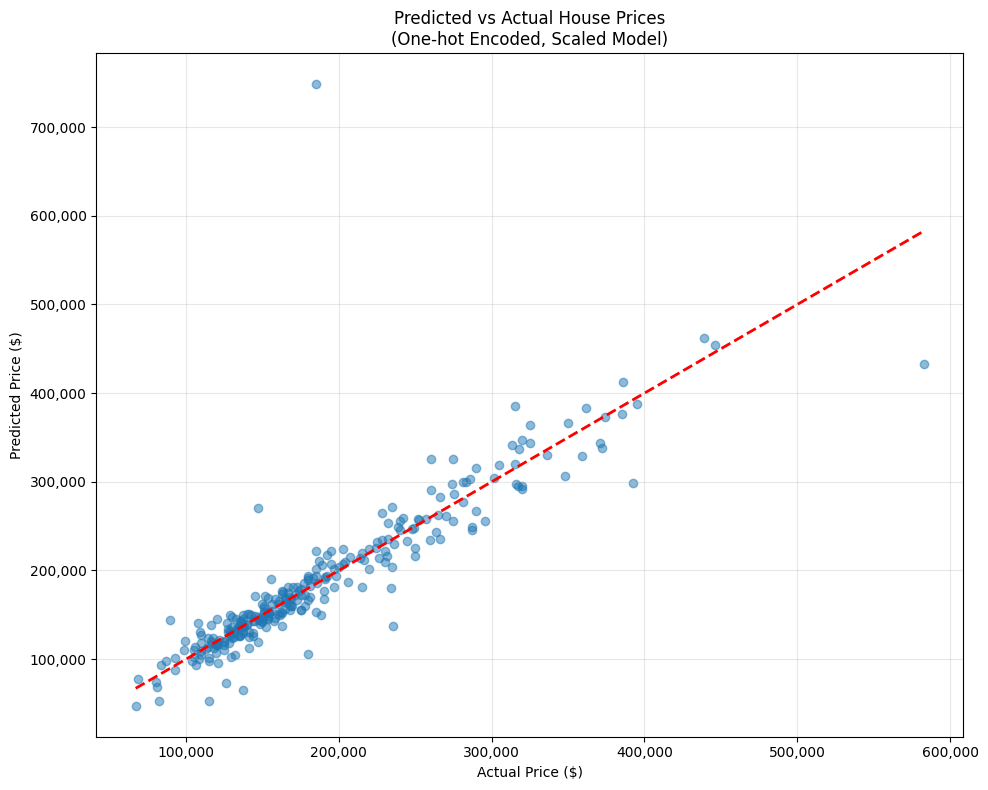


R-squared score on test set: 0.8159


In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
# Create the prediction vs actual plot
plt.figure(figsize=(10, 8))
plt.scatter(y2_test_actual, y2_test_pred, alpha=0.5)
plt.plot([y2_test_actual.min(), y2_test_actual.max()], 
         [y2_test_actual.min(), y2_test_actual.max()], 
         'r--', lw=2)

plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title('Predicted vs Actual House Prices\n(One-hot Encoded, Scaled Model)')

# Format axis labels to show thousands with comma
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

# Add grid for better readability
plt.grid(True, alpha=0.3)

# Adjust layout to prevent label cutoff
plt.tight_layout()

plt.show()

# Calculate R-squared for test set
r2_score = model2.score(X2_test_scaled, y2_test_transformed)
print(f"\nR-squared score on test set: {r2_score:.4f}")
